In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
train = pd.read_csv("fraudTrain.csv")
test = pd.read_csv("fraudTest.csv")

In [3]:
drop_cols = [
    'Unnamed: 0',
    'trans_date_trans_time',
    'cc_num',
    'first',
    'last',
    'street',
    'trans_num',
    'dob'
]

train = train.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)

In [4]:
categorical_cols = [
    'merchant',
    'category',
    'gender',
    'city',
    'state',
    'job'
]

combined = pd.concat([train, test], axis=0)

for col in categorical_cols:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col].astype(str))

train = combined.iloc[:len(train)].copy()
test = combined.iloc[len(train):].copy()

print("Encoding completed successfully!")

Encoding completed successfully!


In [5]:
X_train = train.drop('is_fraud', axis=1)
y_train = train['is_fraud']

X_test = test.drop('is_fraud', axis=1)
y_test = test['is_fraud']

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9971352428115648
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.72      0.42      0.53      2145

    accuracy                           1.00    555719
   macro avg       0.86      0.71      0.76    555719
weighted avg       1.00      1.00      1.00    555719



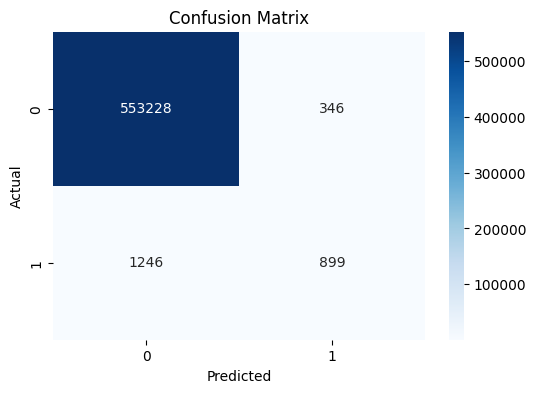

In [9]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [10]:
importance = pd.DataFrame({
    'Feature': train.drop('is_fraud', axis=1).columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

       Feature  Importance
2          amt    0.410004
1     category    0.163356
11   unix_time    0.067462
13  merch_long    0.051850
12   merch_lat    0.051621
0     merchant    0.043941
9     city_pop    0.039002
10         job    0.030971
4         city    0.030834
7          lat    0.028782


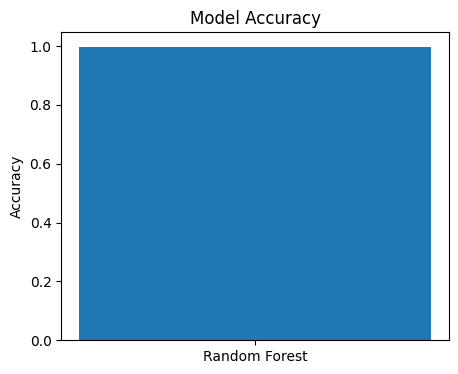

In [11]:
accuracy = accuracy_score(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

plt.bar(
    ["Random Forest"],
    [accuracy]
)

plt.title("Model Accuracy")
plt.ylabel("Accuracy")

plt.show()